In [1]:
import os
os.chdir("../")

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt


from solidification.configs.train_fno_pi import Configs
configs = Configs()

from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})




In [3]:
save_fig_dir = "./figures/"

In [4]:
# from model import model1d
from solidification.model2d import get_model2d

model_kwargs = {
   'modes_x': configs.modes_x,
   'modes_y': configs.modes_x,
   'width': configs.width,
   'depth': configs.depth,
   'activation': getattr(jax.nn, configs.activation),
   'key': jax.random.PRNGKey(0),
}

model_skeleton = get_model2d(
   configs.model_type,
   configs.in_channels,
   configs.out_channels,
   **model_kwargs
)

save_dir_fno = "/root/autodl-tmp/runs/solidification/FNO_experiment/"
weight_fno = os.path.join(save_dir_fno, f"epoch_3200.eqx")
model_fno = eqx.tree_deserialise_leaves(weight_fno, model_skeleton)

In [5]:
# data = jnp.load("./dataset_split.npz")
data = jnp.load(os.path.join(configs.data_dir, "dataset_split.npz"))

# Xs, Ys = data["train_x"], data["train_y"]
Xs, Ys = data["valid_x"], data["valid_y"]
meshes = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["meshes"]
times = jnp.load(os.path.join(configs.data_dir, "dataset_2d_complete.npz"))["times"]
dt = times[1] - times[0]
# meshes = jnp.transpose(meshes, (2, 0, 1))
meshesx = meshes[0]
meshesy = meshes[1]
Xs.shape, Ys.shape

((250, 5, 129, 129), (250, 2, 129, 129))

In [6]:
test_solutions = jnp.load(os.path.join(configs.test_data_dir, "solutions_grid.npy"))
test_ks = jnp.load(os.path.join(configs.test_data_dir, "K_values.npy")).reshape(-1, 1)
u0 = test_solutions[:, 0, :, :]
y_test = test_solutions[:, 1:, :, :]

auto_reg_fn_fno = partial(
    model_fno.auto_reg,
    meshes=meshes,
    steps=200
)
u_preds_fno = jax.vmap(auto_reg_fn_fno)(u0, test_ks)

u_preds_fno.shape

(4, 200, 2, 129, 129)

In [7]:
l2 = jnp.sqrt(jnp.sum((u_preds_fno - y_test) ** 2, axis=(1,3,4)) / jnp.sum(y_test ** 2, axis=(1,3,4)))
l2 = jnp.mean(l2)
print(l2)

0.02311593


2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


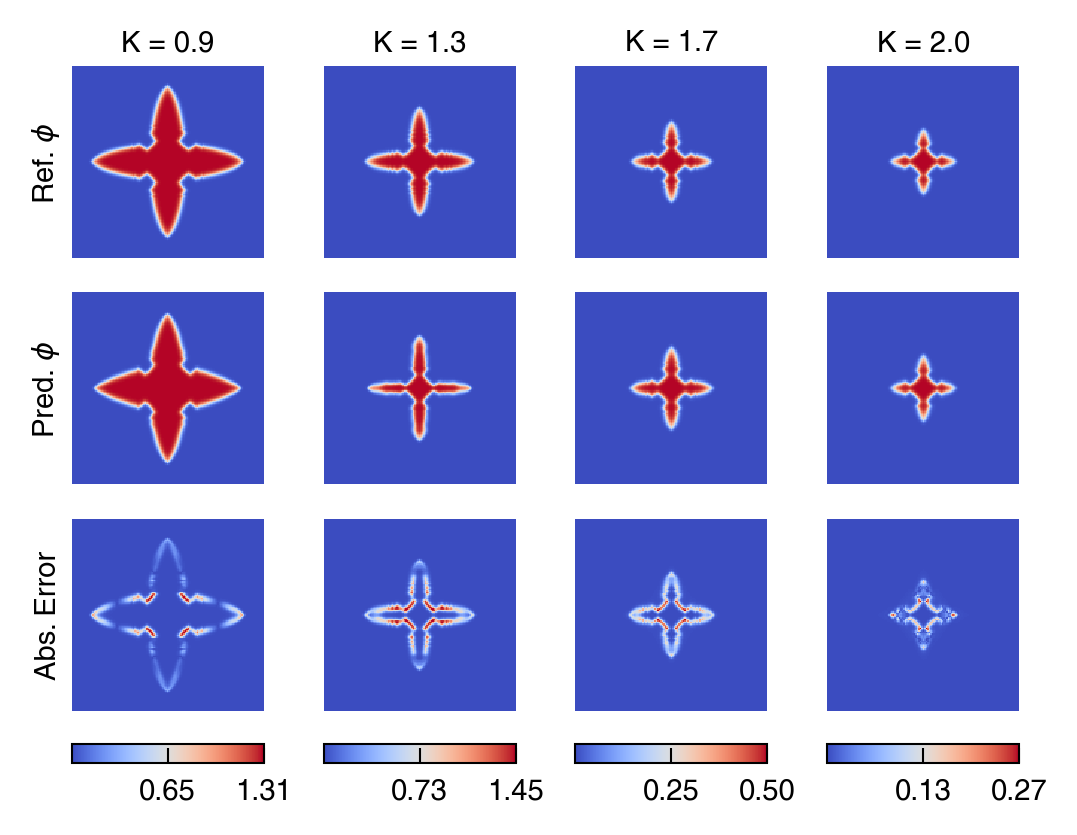

In [8]:
# Final time step, with different ks

meshesx = meshes[0]
meshesy = meshes[1]
example_ths = [0, 1, 2, 3]
idx = -1
component = 0
from matplotlib import gridspec
fig = plt.figure(figsize=(0.9 * len(example_ths), 2.8))
gs = gridspec.GridSpec(4, len(example_ths), figure=fig,
                       width_ratios=[1]*len(example_ths),
                    #    wspace=0.2,hspace=0.2,
                       height_ratios=[1,1,1,0.1,]
                       )
for i, example_th in enumerate(example_ths):
    ax = fig.add_subplot(gs[0, i])
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Ref. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"K = {test_ks[example_th, -1]:.1f}", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    # ax = figure.add_subplot(gs[1, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[1, i])
    ax.pcolormesh(meshesx, meshesy, u_preds_fno[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[2, i])
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds_fno[example_th, idx, component, :, :])
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[3, i])
    # ax.set_axis_off()
    fig.colorbar(diff_ax, cax=ax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3)[1:])
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "solidification_experiments_expanded_krange_phi.pdf"),
            bbox_inches='tight', dpi=450)

2 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


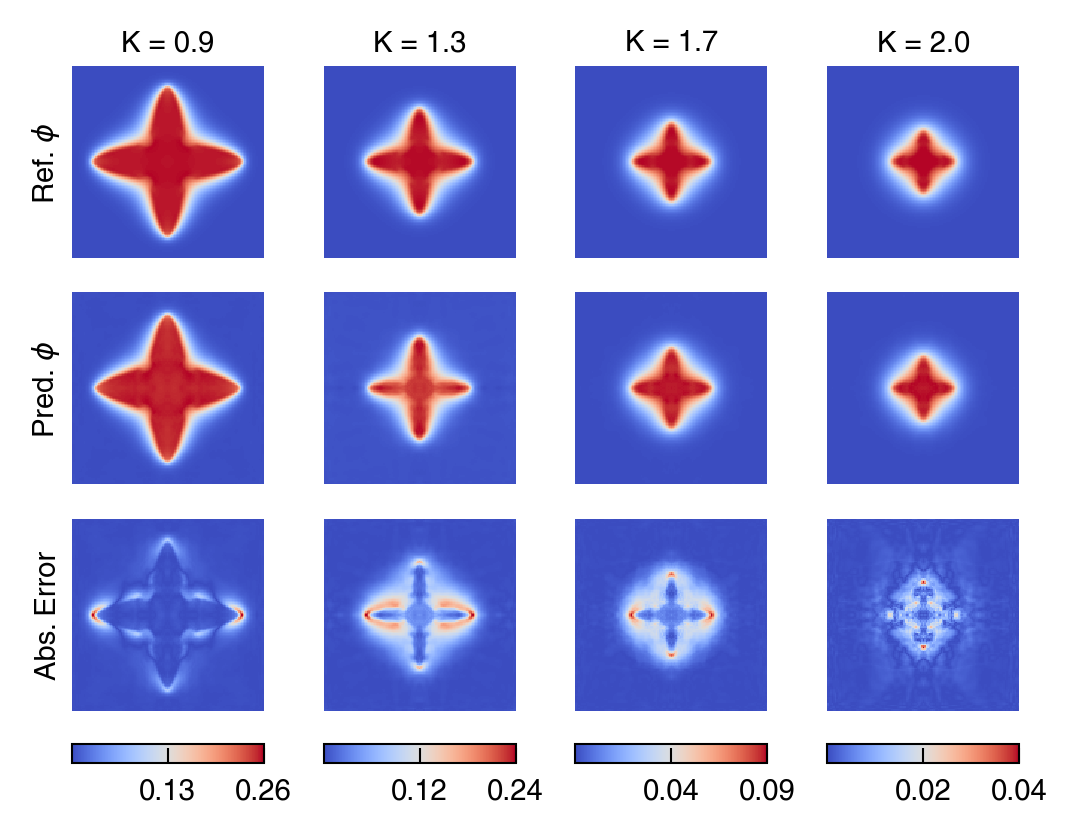

In [9]:
# Final time step, with different ks

meshesx = meshes[0]
meshesy = meshes[1]
example_ths = [0, 1, 2, 3]
idx = -1
component = 1
from matplotlib import gridspec
fig = plt.figure(figsize=(0.9 * len(example_ths), 2.8))
gs = gridspec.GridSpec(4, len(example_ths), figure=fig,
                       width_ratios=[1]*len(example_ths),
                    #    wspace=0.2,hspace=0.2,
                       height_ratios=[1,1,1,0.1,]
                       )
for i, example_th in enumerate(example_ths):
    ax = fig.add_subplot(gs[0, i])
    ax.pcolormesh(meshesx, meshesy, y_test[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Ref. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.text(0.5, 1.05, f"K = {test_ks[example_th, -1]:.1f}", ha="center", va="bottom", transform=ax.transAxes)
    ax.set_aspect('equal')

    # ax = figure.add_subplot(gs[1, i]) # this is a empty row for spacing

    ax = fig.add_subplot(gs[1, i])
    ax.pcolormesh(meshesx, meshesy, u_preds_fno[example_th, idx, component, :, :], 
                  shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, r"Pred. $\phi$", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[2, i])
    diff = jnp.abs(y_test[example_th, idx, component, :, :] - u_preds_fno[example_th, idx, component, :, :])
    diff_ax = ax.pcolormesh(meshesx, meshesy, diff, shading='auto', cmap='coolwarm', rasterized=True)
    if i == 0:
        ax.text(-0.05, 0.5, "Abs. Error", ha="right", va="center", transform=ax.transAxes, rotation=90)
    ax.set_axis_off()
    ax.set_aspect('equal')

    ax = fig.add_subplot(gs[3, i])
    # ax.set_axis_off()
    fig.colorbar(diff_ax, cax=ax, orientation='horizontal', 
                 format='%.2f', ticks=jnp.linspace(0, jnp.max(diff), num=3)[1:])
fig.tight_layout()
fig.savefig(os.path.join(save_fig_dir, "solidification_experiments_expanded_krange_T.pdf"),
            bbox_inches='tight', dpi=450)

In [11]:
import numpy as np
from skimage.segmentation import find_boundaries
from scipy.spatial.distance import directed_hausdorff

def hausdorff_from_arrays(pred, ref, dx=1.0):
    pred_mask = pred >= 0.
    ref_mask  = ref  >= 0.

    pred_bd = find_boundaries(pred_mask, mode='inner')
    ref_bd  = find_boundaries(ref_mask,  mode='inner')

    pred_pts = np.column_stack(np.nonzero(pred_bd))
    ref_pts  = np.column_stack(np.nonzero(ref_bd))

    d1 = directed_hausdorff(pred_pts, ref_pts)[0]
    d2 = directed_hausdorff(ref_pts, pred_pts)[0]

    return max(d1, d2)


dx = meshes[0, 0, 1] - meshes[0, 0, 0]  # normalized
dy = meshes[1, 1, 0] - meshes[1, 0, 0]  # normalized

hd_distances_pino = []
hd_distances_fno = []
for example_th in range(y_test.shape[0]):
    y_test_final = np.array(y_test[example_th, -1, 0, :, :])
    # u_preds_final = np.array(u_preds[example_th, -1, 0, :, :])
    u_preds_fno_final = np.array(u_preds_fno[example_th, -1, 0, :, :])
    # hd_distance_pino = hausdorff_from_arrays(u_preds_final, y_test_final, dx=dx)
    hd_distance_fno = hausdorff_from_arrays(u_preds_fno_final, y_test_final, dx=dx)
    # hd_distances_pino.append(hd_distance_pino)
    hd_distances_fno.append(hd_distance_fno)
    
# use relative hd distance, normalized by mesh size
# hd_distances_pino = np.array(hd_distances_pino)
hd_distances_fno = np.array(hd_distances_fno)
# print("PINO Hausdorff Distance (mean ± std): "+
#       f"{hd_distances_pino.mean():.4f} ± {hd_distances_pino.std():.4f} (normalized by dx)")
print("FNO Hausdorff Distance (mean ± std): "+
      f"{hd_distances_fno.mean():.4f} ± {hd_distances_fno.std():.4f} (normalized by dx)")


FNO Hausdorff Distance (mean ± std): 1.8090 ± 0.8529 (normalized by dx)
